# **Install conda and rdkit**

In [ ]:
! wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
! chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
! bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
! conda install -c rdkit rdkit -y
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')

--2023-03-13 11:12:15--  https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.131.3, 104.16.130.3, 2606:4700::6810:8203, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.131.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85055499 (81M) [application/x-sh]
Saving to: ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh’

Miniconda3-py37_4.8 100%[===================>]  81.12M   147MB/s    in 0.6s    

2023-03-13 11:12:16 (147 MB/s) - ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh’ saved [85055499/85055499]

PREFIX=/usr/local
Unpacking payload ...
Solving environment: | / - done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - _libgcc_mutex==0.1=main
    - asn1crypto==1.3.0=py37_0
    - ca-certificates==2020.1.1=0
    - certifi==2019.11.28=py37_0
    - cffi==1.14.0=py37h2e261b9_0
    - chardet==3.0.4=py37_1003
    - conda-package-handling==1.6.0=p

## Load bioactivity data

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('bioactivity_preprocessed_data.csv')

# ***Calculate Lipinski descriptors***

Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the druglikeness of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the Rule-of-Five or Lipinski's Rule.

The Lipinski's Rule stated the following:

Molecular weight < 500 Dalton
Octanol-water partition coefficient (LogP) < 5
Hydrogen bond donors < 5
Hydrogen bond acceptors < 10




Import *libraries*

In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

## ***Calculate descriptors***

In [ ]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem) 
        moldata.append(mol)
       
    baseData= np.arange(1,1)
    i=0  
    for mol in moldata:        
       
        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
           
        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])   
    
        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1      
    
    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]   
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)
    
    return descriptors

In [ ]:
df_lipinski = lipinski(df.canonical_smiles)

**Combine DataFrames** *italicized text*

Let's take a look at the 2 DataFrames that will be combined.

In [ ]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,430.512,3.62370,1.0,6.0
1,512.617,6.01830,1.0,5.0
2,543.689,5.71600,1.0,5.0
3,388.475,3.85310,1.0,5.0
4,386.459,3.60710,1.0,5.0
5,503.624,4.79170,1.0,5.0
6,428.540,4.77740,1.0,5.0
7,546.634,6.26650,1.0,5.0
8,484.563,5.23810,1.0,5.0
9,561.729,5.27890,1.0,6.0


In [ ]:
df

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value
0,CHEMBL435953,CCCC1=NC2(CCOCC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[...,active,8.00
1,CHEMBL38161,CCCC1=NC(c2ccccc2)(c2ccccc2)C(=O)N1Cc1ccc(-c2c...,active,300.00
2,CHEMBL286134,CCCCC1=NC2(CCCC2)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(...,active,1.00
3,CHEMBL37892,CCCC1=NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[nH]...,active,4.00
4,CHEMBL290180,CCCC1=NC2(CC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[nH]...,active,3.00
5,CHEMBL39352,CCCC1=NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(=O)...,active,3.00
6,CHEMBL290614,CCCC1=NC2(CCCCC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[...,active,3.00
7,CHEMBL39542,O=C1N(Cc2ccc(-c3ccccc3-c3nn[nH]n3)cc2)C(c2cccc...,intermediate,1400.00
8,CHEMBL39978,CC1=NC(c2ccccc2)(c2ccccc2)C(=O)N1Cc1ccc(-c2ccc...,active,100.00
9,CHEMBL39996,CCCC1=NC2(CCSCC2)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(...,active,1.00



Now, let's combine the 2 DataFrame

In [ ]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [ ]:
df_combined

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL435953,CCCC1=NC2(CCOCC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[...,active,8.00,430.512,3.62370,1.0,6.0
1,CHEMBL38161,CCCC1=NC(c2ccccc2)(c2ccccc2)C(=O)N1Cc1ccc(-c2c...,active,300.00,512.617,6.01830,1.0,5.0
2,CHEMBL286134,CCCCC1=NC2(CCCC2)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(...,active,1.00,543.689,5.71600,1.0,5.0
3,CHEMBL37892,CCCC1=NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[nH]...,active,4.00,388.475,3.85310,1.0,5.0
4,CHEMBL290180,CCCC1=NC2(CC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[nH]...,active,3.00,386.459,3.60710,1.0,5.0
5,CHEMBL39352,CCCC1=NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(=O)...,active,3.00,503.624,4.79170,1.0,5.0
6,CHEMBL290614,CCCC1=NC2(CCCCC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[...,active,3.00,428.540,4.77740,1.0,5.0
7,CHEMBL39542,O=C1N(Cc2ccc(-c3ccccc3-c3nn[nH]n3)cc2)C(c2cccc...,intermediate,1400.00,546.634,6.26650,1.0,5.0
8,CHEMBL39978,CC1=NC(c2ccccc2)(c2ccccc2)C(=O)N1Cc1ccc(-c2ccc...,active,100.00,484.563,5.23810,1.0,5.0
9,CHEMBL39996,CCCC1=NC2(CCSCC2)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(...,active,1.00,561.729,5.27890,1.0,6.0


# **Convert IC50 to pIC50**

To allow IC50 data to be more uniformly distributed, we will convert IC50 to the negative logarithmic scale which is essentially -log10(IC50).

This custom function pIC50() will accept a DataFrame as input and will:

Take the IC50 values from the standard_value column and converts it from nM to M by multiplying the value by 10 −9 
Take the molar value and apply -log10
Delete the standard_value column and create a new pIC50 column

In [ ]:
import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', 1)
        
    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative

In [ ]:
df_combined.standard_value.describe()

count    5.400000e+01
mean     5.437824e+04
std      3.945514e+05
min      4.000000e-01
25%      4.080000e+00
50%      7.850000e+01
75%      2.827500e+02
max      2.900000e+06
Name: standard_value, dtype: float64

In [ ]:
-np.log10( (10**-9)* 100000000 )

1.0

In [ ]:
-np.log10( (10**-9)* 10000000000 )

-1.0

In [ ]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', 1)
        
    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [ ]:
df_norm = norm_value(df_combined)
df_norm

<ipython-input-15-5b44499df3ba>:10: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  x = input.drop('standard_value', 1)


,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL435953,CCCC1=NC2(CCOCC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[...,active,430.512,3.62370,1.0,6.0,8.00
1,CHEMBL38161,CCCC1=NC(c2ccccc2)(c2ccccc2)C(=O)N1Cc1ccc(-c2c...,active,512.617,6.01830,1.0,5.0,300.00
2,CHEMBL286134,CCCCC1=NC2(CCCC2)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(...,active,543.689,5.71600,1.0,5.0,1.00
3,CHEMBL37892,CCCC1=NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[nH]...,active,388.475,3.85310,1.0,5.0,4.00
4,CHEMBL290180,CCCC1=NC2(CC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[nH]...,active,386.459,3.60710,1.0,5.0,3.00
5,CHEMBL39352,CCCC1=NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(=O)...,active,503.624,4.79170,1.0,5.0,3.00
6,CHEMBL290614,CCCC1=NC2(CCCCC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[...,active,428.540,4.77740,1.0,5.0,3.00
7,CHEMBL39542,O=C1N(Cc2ccc(-c3ccccc3-c3nn[nH]n3)cc2)C(c2cccc...,intermediate,546.634,6.26650,1.0,5.0,1400.00
8,CHEMBL39978,CC1=NC(c2ccccc2)(c2ccccc2)C(=O)N1Cc1ccc(-c2ccc...,active,484.563,5.23810,1.0,5.0,100.00
9,CHEMBL39996,CCCC1=NC2(CCSCC2)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(...,active,561.729,5.27890,1.0,6.0,1.00


In [ ]:
df_norm.standard_value_norm.describe()

count    5.400000e+01
mean     5.437824e+04
std      3.945514e+05
min      4.000000e-01
25%      4.080000e+00
50%      7.850000e+01
75%      2.827500e+02
max      2.900000e+06
Name: standard_value_norm, dtype: float64

In [ ]:
df_final = pIC50(df_norm)
df_final

<ipython-input-11-715877a2f74e>:11: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  x = input.drop('standard_value_norm', 1)


,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL435953,CCCC1=NC2(CCOCC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[...,active,430.512,3.62370,1.0,6.0,8.096910
1,CHEMBL38161,CCCC1=NC(c2ccccc2)(c2ccccc2)C(=O)N1Cc1ccc(-c2c...,active,512.617,6.01830,1.0,5.0,6.522879
2,CHEMBL286134,CCCCC1=NC2(CCCC2)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(...,active,543.689,5.71600,1.0,5.0,9.000000
3,CHEMBL37892,CCCC1=NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[nH]...,active,388.475,3.85310,1.0,5.0,8.397940
4,CHEMBL290180,CCCC1=NC2(CC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[nH]...,active,386.459,3.60710,1.0,5.0,8.522879
5,CHEMBL39352,CCCC1=NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(=O)...,active,503.624,4.79170,1.0,5.0,8.522879
6,CHEMBL290614,CCCC1=NC2(CCCCC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[...,active,428.540,4.77740,1.0,5.0,8.522879
7,CHEMBL39542,O=C1N(Cc2ccc(-c3ccccc3-c3nn[nH]n3)cc2)C(c2cccc...,intermediate,546.634,6.26650,1.0,5.0,5.853872
8,CHEMBL39978,CC1=NC(c2ccccc2)(c2ccccc2)C(=O)N1Cc1ccc(-c2ccc...,active,484.563,5.23810,1.0,5.0,7.000000
9,CHEMBL39996,CCCC1=NC2(CCSCC2)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(...,active,561.729,5.27890,1.0,6.0,9.000000


In [ ]:
df_final.pIC50.describe()

count    54.000000
mean      7.287739
std       1.339087
min       2.537602
25%       6.549175
50%       7.105351
75%       8.389584
max       9.397940
Name: pIC50, dtype: float64

lets save this to csv 

In [ ]:
df_final.to_csv('bioactivity_preprocessed_data.csv')

Removing the 'intermediate' bioactivity class

Here, we will be removing the intermediate class from our data set.

In [ ]:
df_2class = df_final[df_final.bioactivity_class != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL435953,CCCC1=NC2(CCOCC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[...,active,430.512,3.62370,1.0,6.0,8.096910
1,CHEMBL38161,CCCC1=NC(c2ccccc2)(c2ccccc2)C(=O)N1Cc1ccc(-c2c...,active,512.617,6.01830,1.0,5.0,6.522879
2,CHEMBL286134,CCCCC1=NC2(CCCC2)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(...,active,543.689,5.71600,1.0,5.0,9.000000
3,CHEMBL37892,CCCC1=NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[nH]...,active,388.475,3.85310,1.0,5.0,8.397940
4,CHEMBL290180,CCCC1=NC2(CC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[nH]...,active,386.459,3.60710,1.0,5.0,8.522879
5,CHEMBL39352,CCCC1=NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(=O)...,active,503.624,4.79170,1.0,5.0,8.522879
6,CHEMBL290614,CCCC1=NC2(CCCCC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nn[...,active,428.540,4.77740,1.0,5.0,8.522879
8,CHEMBL39978,CC1=NC(c2ccccc2)(c2ccccc2)C(=O)N1Cc1ccc(-c2ccc...,active,484.563,5.23810,1.0,5.0,7.000000
9,CHEMBL39996,CCCC1=NC2(CCSCC2)C(=O)N1Cc1ccc(-c2ccccc2S(=O)(...,active,561.729,5.27890,1.0,6.0,9.000000
10,CHEMBL1513,CCCCC1=NC2(CCCC2)C(=O)N1Cc1ccc(-c2ccccc2-c2nnn...,active,428.540,4.77740,1.0,5.0,9.045757



Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors

Import library

In [ ]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

## **Frequency plot of the 2 bioactivity classes**

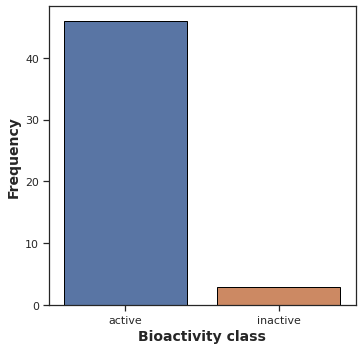

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

# **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

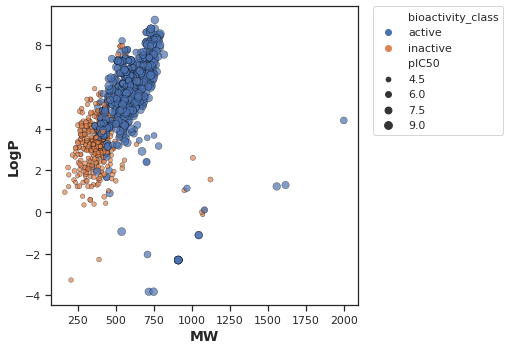

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

# **Box plots**

## **pIC50**

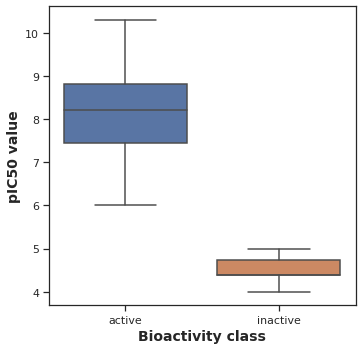

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

# **Statistical analysis | Mann-Whitney U Test**

In [ ]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  active = df[df['bioactivity_class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  inactive = df[df['bioactivity_class'] == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'
  
  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [ ]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,236250.0,1.888155e-152,0.05,Different distribution (reject H0)


**MW**

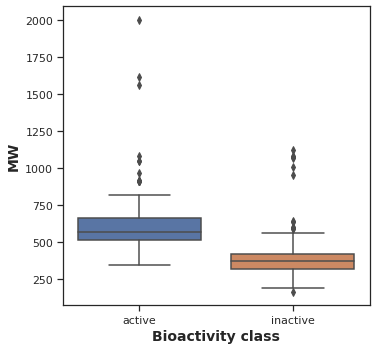

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [ ]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,220149.5,4.430655e-114,0.05,Different distribution (reject H0)


## **LogP**

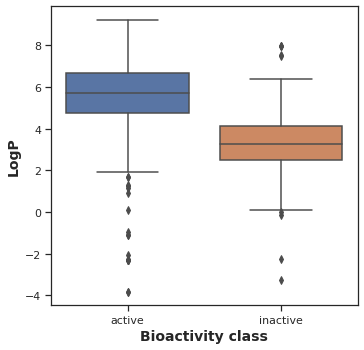

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

## **Statistical analysis | Mann-Whitney U Test**

In [ ]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,207609.5,3.313504e-88,0.05,Different distribution (reject H0)


## **NumHDonors**

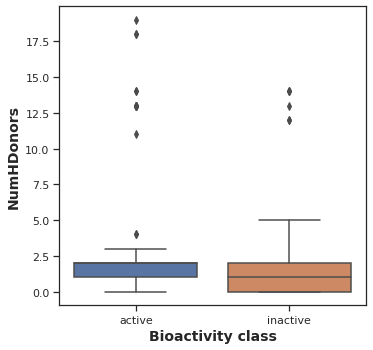

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

***Statistical analysis | Mann-Whitney U Test***

In [ ]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,154660.5,1.225015e-17,0.05,Different distribution (reject H0)


***NumHAcceptors***

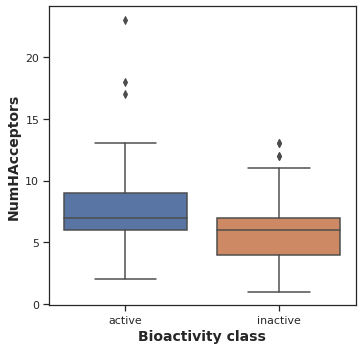

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [ ]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,168541.5,8.492989e-30,0.05,Different distribution (reject H0)


## **Interpretation of Statistical Resultst**

**Box Plots**
**pIC50 values**

Taking a look at pIC50 values, the actives and inactives displayed statistically significant difference, which is to be expected since threshold values (IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives, corresponding to pIC50 > 6 = Actives and pIC50 < 5 = Inactives) were used to define actives and inactives.

Lipinski's descriptors
All of the 4 Lipinski's descriptors exhibited statistically significant difference between the actives and inactives.

# **Zip files**

In [ ]:
! zip -r results.zip . -i *.csv *.pdf

  adding: plot_ic50.pdf (deflated 36%)
  adding: plot_MW.pdf (deflated 40%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 11%)
  adding: plot_bioactivity_class.pdf (deflated 38%)
  adding: mannwhitneyu_LogP.csv (deflated 9%)
  adding: plot_LogP.pdf (deflated 38%)
  adding: mannwhitneyu_pIC50.csv (deflated 11%)
  adding: plot_NumHDonors.pdf (deflated 39%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 11%)
  adding: plot_MW_vs_LogP.pdf (deflated 3%)
  adding: mannwhitneyu_MW.csv (deflated 9%)
  adding: plot_NumHAcceptors.pdf (deflated 39%)
  adding: bioactivity_preprocessed_data.csv (deflated 78%)


# **Bioinformatics Project - Computational Drug Discovery [Part 3] Descriptor Calculation and Dataset Preparationt**

## **Download PaDEL-Descriptor**

In [ ]:
! wget https://github.com/dataprofessor/bioinformatics/raw/master/padel.zip
! wget https://github.com/dataprofessor/bioinformatics/raw/master/padel.sh

--2023-01-30 05:20:04--  https://github.com/dataprofessor/bioinformatics/raw/master/padel.zip
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dataprofessor/bioinformatics/master/padel.zip [following]
--2023-01-30 05:20:05--  https://raw.githubusercontent.com/dataprofessor/bioinformatics/master/padel.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25768637 (25M) [application/zip]
Saving to: ‘padel.zip’

padel.zip           100%[===================>]  24.57M  --.-KB/s    in 0.09s   

2023-01-30 05:20:06 (286 MB/s) - ‘padel.zip’ saved [25768637/25768637]

--2023-01-30 05:20:06--  https://github

In [ ]:
! unzip padel.zip

Archive:  padel.zip
   creating: PaDEL-Descriptor/
  inflating: __MACOSX/._PaDEL-Descriptor  
  inflating: PaDEL-Descriptor/MACCSFingerprinter.xml  
  inflating: __MACOSX/PaDEL-Descriptor/._MACCSFingerprinter.xml  
  inflating: PaDEL-Descriptor/AtomPairs2DFingerprinter.xml  
  inflating: __MACOSX/PaDEL-Descriptor/._AtomPairs2DFingerprinter.xml  
  inflating: PaDEL-Descriptor/EStateFingerprinter.xml  
  inflating: __MACOSX/PaDEL-Descriptor/._EStateFingerprinter.xml  
  inflating: PaDEL-Descriptor/Fingerprinter.xml  
  inflating: __MACOSX/PaDEL-Descriptor/._Fingerprinter.xml  
  inflating: PaDEL-Descriptor/.DS_Store  
  inflating: __MACOSX/PaDEL-Descriptor/._.DS_Store  
   creating: PaDEL-Descriptor/license/
  inflating: __MACOSX/PaDEL-Descriptor/._license  
  inflating: PaDEL-Descriptor/KlekotaRothFingerprintCount.xml  
  inflating: __MACOSX/PaDEL-Descriptor/._KlekotaRothFingerprintCount.xml  
  inflating: PaDEL-Descriptor/config  
  inflating: __MACOSX/PaDEL-Descriptor/._config  
  inf

## **Load bioactivity data**

Download the curated ChEMBL bioactivity data that has been pre-processed from Parts 1 and 2 of this Bioinformatics Project series. Here we will be using the bioactivity_data_3class_pIC50.csv file that essentially contain the pIC50 values that we will be using for building a regression model.

In [ ]:
df_2class

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL813,CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccc(C(=O)...,active,424.522,4.7444,2.0,5.0,8.136677
1,CHEMBL813,CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccc(C(=O)...,active,424.522,4.7444,2.0,5.0,8.698970
2,CHEMBL55508,CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccccc1,active,380.513,5.0462,1.0,4.0,6.356547
3,CHEMBL97533,CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccc(C(=O)...,active,474.582,5.8976,2.0,5.0,7.508638
4,CHEMBL97533,CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccc(C(=O)...,active,474.582,5.8976,2.0,5.0,8.920819
...,...,...,...,...,...,...,...,...
1172,CHEMBL4856425,CCCCC1=NC(C)(c2ccccc2)C(=O)N1Cc1ccc(-c2ccccc2-...,active,464.573,5.3800,1.0,5.0,7.602060
1174,CHEMBL4859498,CCCCC1NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2-c2nnn[nH...,active,404.518,3.7604,2.0,5.0,6.408935
1175,CHEMBL4877651,CCCCC1=NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2-c2nnn[n...,active,402.502,4.2432,1.0,5.0,7.494850
1177,CHEMBL4854916,CCCC[C@H]1N(Cc2ccc(-c3ccccc3-c3nnn[nH]3)cc2)C(...,inactive,416.529,3.8566,1.0,5.0,5.000000


In [ ]:
df3= df_2class



In [ ]:
df3

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL813,CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccc(C(=O)...,active,424.522,4.7444,2.0,5.0,8.136677
1,CHEMBL813,CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccc(C(=O)...,active,424.522,4.7444,2.0,5.0,8.698970
2,CHEMBL55508,CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccccc1,active,380.513,5.0462,1.0,4.0,6.356547
3,CHEMBL97533,CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccc(C(=O)...,active,474.582,5.8976,2.0,5.0,7.508638
4,CHEMBL97533,CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccc(C(=O)...,active,474.582,5.8976,2.0,5.0,8.920819
...,...,...,...,...,...,...,...,...
1172,CHEMBL4856425,CCCCC1=NC(C)(c2ccccc2)C(=O)N1Cc1ccc(-c2ccccc2-...,active,464.573,5.3800,1.0,5.0,7.602060
1174,CHEMBL4859498,CCCCC1NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2-c2nnn[nH...,active,404.518,3.7604,2.0,5.0,6.408935
1175,CHEMBL4877651,CCCCC1=NC(C)(C)C(=O)N1Cc1ccc(-c2ccccc2-c2nnn[n...,active,402.502,4.2432,1.0,5.0,7.494850
1177,CHEMBL4854916,CCCC[C@H]1N(Cc2ccc(-c3ccccc3-c3nnn[nH]3)cc2)C(...,inactive,416.529,3.8566,1.0,5.0,5.000000


In [ ]:
selection = ['canonical_smiles','molecule_chembl_id']
df3_selection = df3[selection]
df3_selection.to_csv('molecule.smi', sep='\t', index=False, header=False)

In [ ]:
! cat molecule.smi | head -5

CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccc(C(=O)O)cc1	CHEMBL813
CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccc(C(=O)O)cc1	CHEMBL813
CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccccc1	CHEMBL55508
CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccc(C(=O)O)c2ccccc12	CHEMBL97533
CCCCc1ncc(/C=C(\Cc2cccs2)C(=O)O)n1Cc1ccc(C(=O)O)c2ccccc12	CHEMBL97533


In [ ]:
! cat molecule.smi | wc -l

1025


## **Calculate fingerprint descriptors**

Calculate PaDEL descriptors

In [ ]:
! cat padel.sh

java -Xms1G -Xmx1G -Djava.awt.headless=true -jar ./PaDEL-Descriptor/PaDEL-Descriptor.jar -removesalt -standardizenitro -fingerprints -descriptortypes ./PaDEL-Descriptor/PubchemFingerprinter.xml -dir ./ -file descriptors_output.csv


In [ ]:
! bash padel.sh

Processing CHEMBL813 in molecule.smi (1/1025). 
Processing CHEMBL813 in molecule.smi (2/1025). 
Processing CHEMBL97533 in molecule.smi (4/1025). Average speed: 4.59 s/mol.
Processing CHEMBL55508 in molecule.smi (3/1025). Average speed: 4.55 s/mol.
Processing CHEMBL74556 in molecule.smi (6/1025). Average speed: 1.56 s/mol.
Processing CHEMBL97533 in molecule.smi (5/1025). Average speed: 1.90 s/mol.
Processing CHEMBL311484 in molecule.smi (7/1025). Average speed: 1.46 s/mol.
Processing CHEMBL73876 in molecule.smi (8/1025). Average speed: 1.35 s/mol.
Processing CHEMBL305647 in molecule.smi (10/1025). Average speed: 1.22 s/mol.
Processing CHEMBL302102 in molecule.smi (9/1025). Average speed: 1.35 s/mol.
Processing CHEMBL74442 in molecule.smi (11/1025). Average speed: 1.26 s/mol.
Processing CHEMBL17487 in molecule.smi (12/1025). Average speed: 1.31 s/mol.
Processing CHEMBL305956 in molecule.smi (13/1025). Average speed: 1.29 s/mol.
Processing CHEMBL278176 in molecule.smi (14/1025). Average s

In [ ]:
! ls -l

total 110872
-rw-r--r-- 1 root root   176646 Jan 30 05:19 bioactivity_preprocessed_data.csv
-rw-r--r-- 1 root root  1833189 Jan 30 05:26 descriptors_output.csv
drwxr-xr-x 3 root root     4096 Jan 30 05:20 __MACOSX
-rw-r--r-- 1 root root      125 Jan 30 05:19 mannwhitneyu_LogP.csv
-rw-r--r-- 1 root root      123 Jan 30 05:19 mannwhitneyu_MW.csv
-rw-r--r-- 1 root root      133 Jan 30 05:19 mannwhitneyu_NumHAcceptors.csv
-rw-r--r-- 1 root root      131 Jan 30 05:19 mannwhitneyu_NumHDonors.csv
-rw-r--r-- 1 root root      127 Jan 30 05:19 mannwhitneyu_pIC50.csv
-rwxr-xr-x 1 root root 85055499 Mar 11  2020 Miniconda3-py37_4.8.2-Linux-x86_64.sh
-rw-r--r-- 1 root root    81590 Jan 30 05:20 molecule.smi
drwxrwxr-x 4 root root     4096 May 30  2020 PaDEL-Descriptor
-rw-r--r-- 1 root root      231 Jan 30 05:20 padel.sh
-rw-r--r-- 1 root root 25768637 Jan 30 05:20 padel.zip
-rw-r--r-- 1 root root    14443 Jan 30 05:19 plot_bioactivity_class.pdf
-rw-r--r-- 1 root root    15149 Jan 30 05:19 plot_ic5

## **Preparing the X and Y Data Matrices**

X data matrix

In [ ]:
df3_X = pd.read_csv('descriptors_output.csv')

In [ ]:
df3_X

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CHEMBL813,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL813,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CHEMBL55508,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CHEMBL97533,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CHEMBL97533,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,CHEMBL4856425,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1021,CHEMBL4859498,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1022,CHEMBL4877651,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1023,CHEMBL4854916,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df3_X = df3_X.drop(columns=['Name'])
df3_X

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1021,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1022,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1023,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


## **Y variable**

## **Convert IC50 to pIC50**

In [ ]:
df3_Y = df3['pIC50']
df3_Y

0       8.136677
1       8.698970
2       6.356547
3       7.508638
4       8.920819
          ...   
1172    7.602060
1174    6.408935
1175    7.494850
1177    5.000000
1178    8.152427
Name: pIC50, Length: 1025, dtype: float64

## **Combining X and Y variable**

In [ ]:
dataset3 = pd.concat([df3_X,df3_Y], axis=1)
dataset3

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50
0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.136677
1,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.698970
2,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.356547
3,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.508638
4,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.920819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.602060
1174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.408935
1175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.494850
1177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000


In [ ]:
dataset3.to_csv('bioactivitiyvv.csv', index=False)

In [ ]:
import pandas as pd
import numpy as np
from Pubchem import calcPubChemFingerAll
from rdkit import Chem
df = pd.read_csv('bioactivityvv.csv')
df['Molecule'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)
df["FPs"] = df.Molecule.apply(calcPubChemFingerAll)
X = np.stack(df.FPs.values)
df_X = pd.DataFrame(X)
df_X.columns=["Pubchem_"+str(i) for i in range(1, len(df_X.columns) + 1)]
df= pd.concat([df, df_X], axis = 1).drop(["FPs", "Molecule"], axis =1)
df.head()


ModuleNotFoundError: ignored